# 探索性数据分析（EDA）

数据概览 · 目标变量分布 · 缺失值分析 · 时间分布

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from logistics_delay.utils.paths import FIGURES_EDA, ensure_output_dirs
from logistics_delay.data.loader import load_raw_data_with_target

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("[OK] 导入完成")

[OK] 导入完成


In [2]:
# ── 加载数据 ──
df = load_raw_data_with_target()
print(f"列名：{list(df.columns)}")

[loader] 原始数据加载完成: (6880, 32)
[loader] 目标变量构建完成: 延误=4332, 准时=2548
[loader] 延误率: 62.97%
列名：['GpsProvider', 'BookingID', 'Market/Regular', 'BookingID_Date', 'vehicle_no', 'Origin_Location', 'Destination_Location', 'Org_lat_lon', 'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'Current_Location', 'DestinationLocation', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime', 'delay', 'OriginLocation_Code', 'DestinationLocation_Code', 'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID', 'supplierNameCode', 'Material Shipped', 'Answer']


延误（1）：4332 条
准时（0）：2548 条
延误率：62.97%


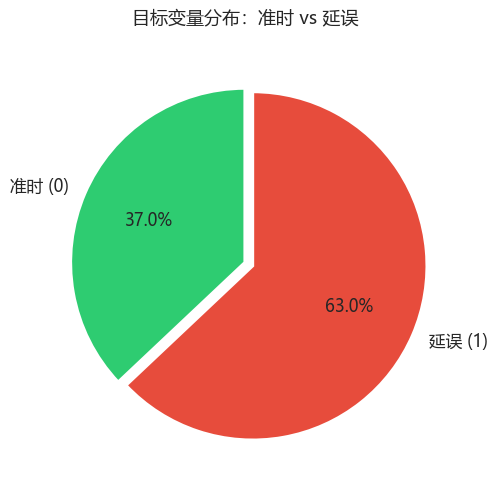

图片已保存到： C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\eda\target_distribution.png


In [3]:
# ── 目标变量分析 ──
counts = df['Answer'].value_counts()
print(f"延误（1）：{counts.get(1)} 条")
print(f"准时（0）：{counts.get(0)} 条")
print(f"延误率：{counts.get(1)/len(df)*100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    [counts.get(0), counts.get(1)], labels=['准时 (0)', '延误 (1)'],
    autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.05),
    textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('目标变量分布：准时 vs 延误', fontsize=13, pad=15)
plt.savefig(FIGURES_EDA /'target_distribution.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("图片已保存到：", FIGURES_EDA /'target_distribution.png')

In [4]:
# ── 缺失值分析 ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例 (%)': missing_pct})
missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)
print(f"存在缺失值的字段：{len(missing_df)} 个")
print(missing_df.to_string())

存在缺失值的字段：16 个
                                    缺失数量  缺失比例 (%)
ontime                              4332     62.97
Driver_MobileNo                     4189     60.89
Minimum_kms_to_be_covered_in_a_day  4060     59.01
Driver_Name                         3429     49.84
delay                               2538     36.89
Current_Location                     964     14.01
Curr_lon                             953     13.85
GpsProvider                          953     13.85
Data_Ping_time                       953     13.85
Curr_lat                             953     13.85
vehicleType                          828     12.03
TRANSPORTATION_DISTANCE_IN_KM        712     10.35
trip_end_date                        194      2.82
actual_eta                            37      0.54
DestinationLocation_Code              27      0.39
OriginLocation_Code                    3      0.04


In [5]:
# ── 时间范围分析 ──
df['trip_start_date'] = pd.to_datetime(df['trip_start_date'], errors='coerce')
print(f"日期范围：{df['trip_start_date'].min().date()} ~ {df['trip_start_date'].max().date()}")
df['year'] = df['trip_start_date'].dt.year
for yr, cnt in df['year'].value_counts().sort_index().items():
    print(f"  {int(yr)}年：{cnt} 条")

日期范围：1899-12-30 ~ 2020-12-03
  1899年：2 条
  2019年：3283 条
  2020年：3595 条


均值：553.9 km | 中位数：160.0 km | 缺失：712 条
图片已保存到： C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\eda\distance_distribution.png


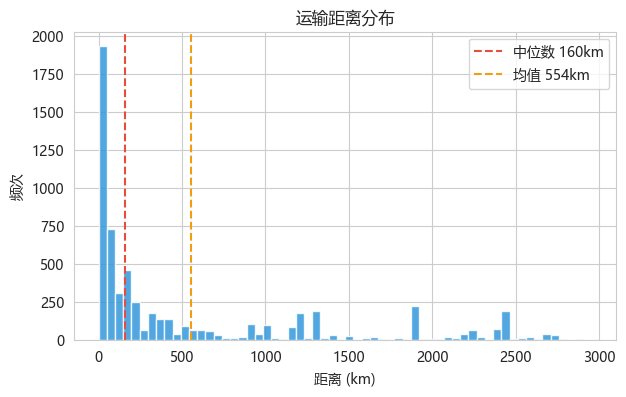

In [6]:
# ── 运输距离分析 ──
dist = df['TRANSPORTATION_DISTANCE_IN_KM'].dropna()
print(f"均值：{dist.mean():.1f} km | 中位数：{dist.median():.1f} km | 缺失：{df['TRANSPORTATION_DISTANCE_IN_KM'].isna().sum()} 条")

plt.figure(figsize=(7, 4))

plt.hist(dist, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(dist.median(), color='#e74c3c', linestyle='--',
            label=f'中位数 {dist.median():.0f}km')
plt.axvline(dist.mean(), color='#f39c12', linestyle='--',
            label=f'均值 {dist.mean():.0f}km')

plt.xlabel('距离 (km)')
plt.ylabel('频次')
plt.title('运输距离分布')
plt.legend()
plt.savefig(FIGURES_EDA / 'distance_distribution.png', dpi=300, bbox_inches='tight')
print("图片已保存到：", FIGURES_EDA / 'distance_distribution.png')

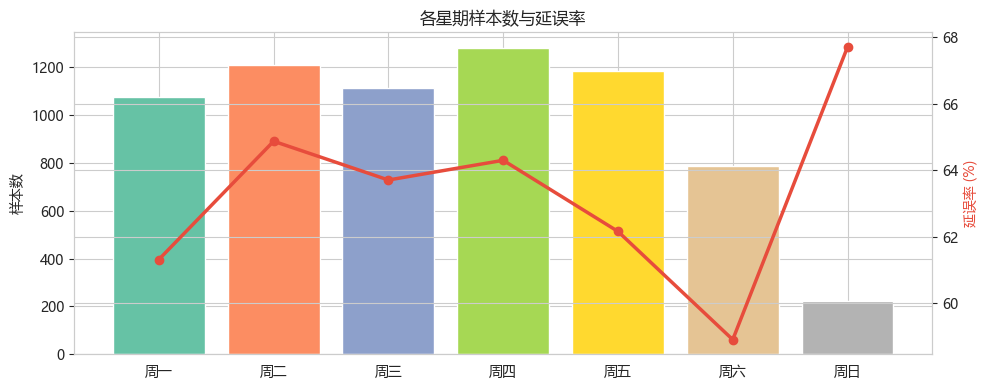

图片已保存到： C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\eda\weekday_distribution.png


In [7]:
# ── 星期分布 ──
df['weekday'] = df['trip_start_date'].dt.dayofweek
wd_stats = df.groupby('weekday')['Answer'].agg(['count', 'mean'])
wd_stats['mean'] = wd_stats['mean'] * 100
weekday_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(7), wd_stats['count'], color=plt.cm.Set2(np.linspace(0, 1, 7)), edgecolor='white')
ax.set_xticks(range(7)); ax.set_xticklabels(weekday_names)
ax.set_ylabel('样本数'); ax.set_title('各星期样本数与延误率')
ax2 = ax.twinx()
ax2.plot(range(7), wd_stats['mean'], 'o-', color='#e74c3c', linewidth=2.5)
ax2.set_ylabel('延误率 (%)', color='#e74c3c')
plt.tight_layout()
plt.savefig(FIGURES_EDA /'weekday_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("图片已保存到：", FIGURES_EDA /'weekday_distribution.png')

In [8]:
print(f"[OK] EDA 完成。总样本：{len(df)}，延误率：{df['Answer'].mean()*100:.2f}%")

[OK] EDA 完成。总样本：6880，延误率：62.97%
